# Brazilian E-Commerce Business Analysis

The Olist Brazilian E-Commerce Dataset on Kaggle Brazilian E-Commerce Public Dataset by Olist is a popular, real commercial dataset featuring 100,000 orders spanning 2016 to 2018 from multiple marketplaces across Brazil.

This notebook investigates business performance using the Olist Brazilian
E-Commerce dataset.
It answers five questions that bear on real decisions:
customer retention, delivery's effect on satisfaction, seller performance,
acquisition cohorts, and logistics bottlenecks.

SQL extracts the data (queries live in `sql/notebook/`); Python visualizes
and interprets it. Each section follows the same arc:
**question → context → query → chart → insight → recommendation.**

**Tools:** SQLite · pandas · matplotlib · python


In [32]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [34]:
conn = sqlite3.connect("file:../data/olist.db?mode=ro", uri=True)

In [35]:
from pathlib import Path
print("CWD:", Path.cwd())
print("data/olist.db here?", (Path.cwd() / "data" / "olist.db").exists())

CWD: /Users/shavkatjon/brazilian-e-market/notebooks
data/olist.db here? False


In [36]:
from pathlib import Path

here = Path.cwd()
project_root = next(p for p in [here, *here.parents] if (p / "data" / "olist.db").exists())

db_path = project_root / "data" / "olist.db"
conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
print("Connected to:", db_path)

Connected to: /Users/shavkatjon/brazilian-e-market/data/olist.db


In [37]:
def run_sql(filename):
    path = project_root / "sql" / "notebook" / filename
    return pd.read_sql_query(path.read_text(encoding="utf-8"), conn)

def save_fig(fig, name):
    out = project_root / "reports" / "figures"
    out.mkdir(parents=True, exist_ok=True)
    fig.savefig(out / f"{name}.png", dpi=300, bbox_inches="tight")

def bar(df, cat, val, title, xlabel, fmt=",.0f"):
    """Horizontal bar chart for rankings. Highest row at the top."""
    fig, ax = plt.subplots()
    ax.barh(df[cat].astype(str), df[val], color="#2C7FB8")
    ax.set_title(title, fontsize=14, weight="bold", pad=12)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()
    for i, v in enumerate(df[val]):
        ax.text(v, i, f" {v:{fmt}}", va="center", fontsize=9)
    fig.tight_layout()
    return fig, ax

def line(df, x, y, title, ylabel):
    """Line chart for a trend over time."""
    fig, ax = plt.subplots()
    ax.plot(df[x].astype(str), df[y], marker="o", color="#2C7FB8")
    ax.set_title(title, fontsize=14, weight="bold", pad=12)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()
    return fig, ax

## Executive KPI Snapshot

The headline numbers that frame everything below.

In [38]:
kpi_sql = """
SELECT
  (SELECT COUNT(DISTINCT customer_unique_id) FROM customers)            AS total_customers,
  (SELECT COUNT(*) FROM orders)                                         AS total_orders,
  (SELECT ROUND(SUM(payment_value), 2) FROM payments)                   AS total_revenue,
  (SELECT ROUND(AVG(review_score), 2) FROM reviews)                     AS avg_review,
  (SELECT ROUND(AVG(julianday(order_delivered_customer_date)
                    - julianday(order_purchase_timestamp)), 1)
     FROM orders
     WHERE order_status = 'delivered'
       AND order_delivered_customer_date IS NOT NULL)                   AS avg_delivery_days,
  (SELECT ROUND(100.0 * SUM(CASE WHEN n > 1 THEN 1 ELSE 0 END) / COUNT(*), 2)
     FROM (SELECT COUNT(o.order_id) AS n
           FROM customers c
           JOIN orders o ON o.customer_id = c.customer_id
           GROUP BY c.customer_unique_id))                              AS repeat_rate_pct
"""
kpi = pd.read_sql_query(kpi_sql, conn).iloc[0]

print(f"Total customers     : {kpi.total_customers:,}")
print(f"Total orders        : {kpi.total_orders:,}")
print(f"Total revenue (GMV) : R$ {kpi.total_revenue:,.2f}")
print(f"Average review      : {kpi.avg_review} / 5")
print(f"Avg delivery time   : {kpi.avg_delivery_days} days")
print(f"Repeat purchase rate: {kpi.repeat_rate_pct}%")

Total customers     : 96,096.0
Total orders        : 99,441.0
Total revenue (GMV) : R$ 16,008,872.12
Average review      : 4.09 / 5
Avg delivery time   : 12.6 days
Repeat purchase rate: 3.12%


## Q1 — Customer Retention & At-Risk Segments

**Question:** how loyal is our customer base, and how many customers have
gone quiet?

**Context:** acquiring customers is expensive. If most customers buy once
and disappear, the lever for growth is acquisition and first-order
experience, not loyalty programs aimed at repeat buyers who barely exist.

In [39]:
segments = run_sql("at_risk_segments.sql")
segments

,segment,customers,avg_spend
0,1: Active,9555,164.85
1,2: Cooling,18231,172.33
2,3: At Risk,39334,162.40
3,4: Churned,27869,166.29


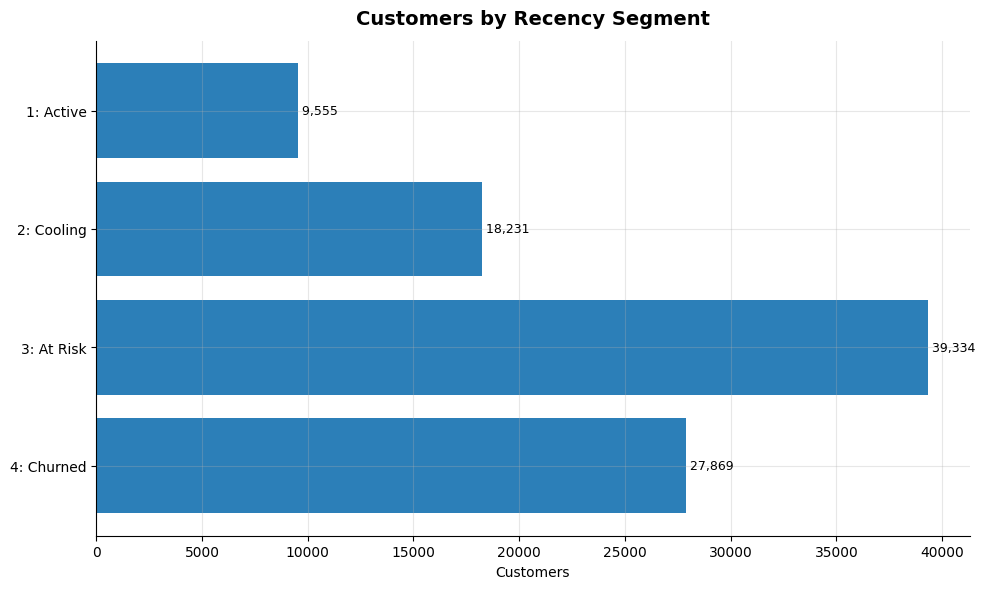

In [40]:
fig, ax = bar(segments, "segment", "customers",
              "Customers by Recency Segment", "Customers")
save_fig(fig, "at_risk_segments")
plt.show()

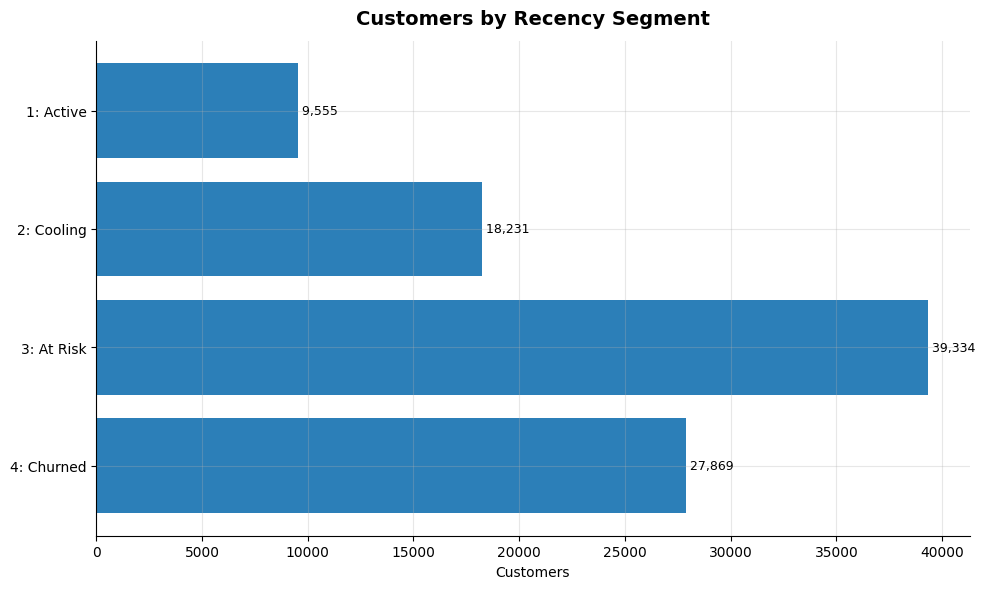

In [41]:
fig, ax = bar(segments, "segment", "customers",
              "Customers by Recency Segment", "Customers")
save_fig(fig, "at_risk_segments")
plt.show()

### Insight
<!-- Look at your output. Which segment dominates? State the count and % share. -->
- The largest segment is **___**, with **___** customers (__% of the base).
- [What this says about how the marketplace actually behaves]

### Recommendation
- [One concrete action that follows directly from the number above]

## Q2 — Delivery Performance vs Review Scores

**Question:** do delivery delays drag down customer satisfaction?

**Context:** late deliveries are a leading cause of bad experiences. If
review scores fall as orders run late, logistics is a satisfaction problem,
not just an operations one.

In [42]:
delivery = run_sql("delivery_vs_review.sql")
delivery

,delivery_status,orders,avg_review
0,1: on time / early,88163,4.29
1,2: 1-3 days late,2636,3.77
2,3: 4-7 days late,1773,2.32
3,4: 8+ days late,3252,1.73


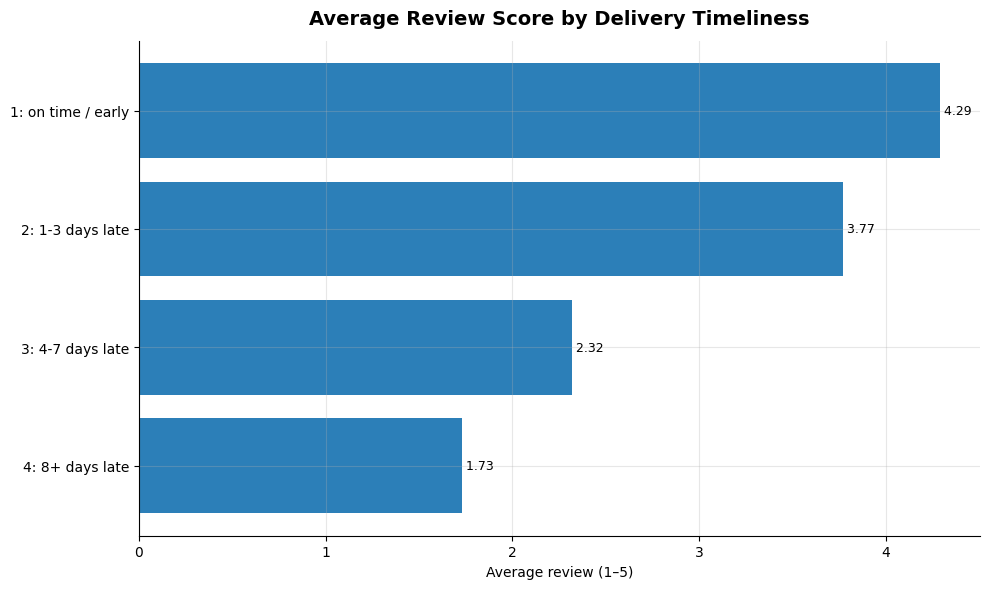

In [43]:
fig, ax = bar(delivery, "delivery_status", "avg_review",
              "Average Review Score by Delivery Timeliness",
              "Average review (1–5)", fmt=".2f")
save_fig(fig, "delivery_vs_review")
plt.show()

### Insight
- On-time orders average **___** stars; orders 8+ days late average **___**.
- [Describe the size of the drop and what it implies]

### Recommendation
- [Action — e.g. where to focus delivery reliability]

## Q3 — Seller Performance

**Question:** which sellers drive revenue, and how do the top sellers score
on ratings and delivery?

**Context:** marketplaces depend on a core of strong sellers. Knowing who
they are — and whether high revenue comes with good service — guides where
to invest support.

In [44]:
sellers = run_sql("seller_scorecard.sql")
sellers["seller_short"] = sellers["seller_id"].str[:8]  # IDs are long hashes
sellers

,seller_id,orders,revenue,avg_review,on_time_pct,seller_short
0,4869f7a5dfa277a7dca6462dcf3b52b2,1124,226987.93,4.15,88.4,4869f7a5
1,53243585a1d6dc2643021fd1853d8905,348,217940.44,4.19,95.7,53243585
2,4a3ca9315b744ce9f8e9374361493884,1772,196882.12,3.85,89.0,4a3ca931
3,fa1c13f2614d7b5c4749cbc52fecda94,578,190917.14,4.37,89.8,fa1c13f2
4,7c67e1448b00f6e969d365cea6b010ab,973,186570.05,3.50,89.9,7c67e144
5,7e93a43ef30c4f03f38b393420bc753a,319,165981.49,4.36,94.4,7e93a43e
6,da8622b14eb17ae2831f4ac5b9dab84a,1311,159816.87,4.18,92.4,da8622b1
7,7a67c85e85bb2ce8582c35f2203ad736,1145,139658.69,4.27,94.1,7a67c85e
8,1025f0e2d44d7041d6cf58b6550e0bfa,910,138208.56,4.01,89.9,1025f0e2
9,955fee9216a65b617aa5c0531780ce60,1261,131836.71,4.20,92.2,955fee92


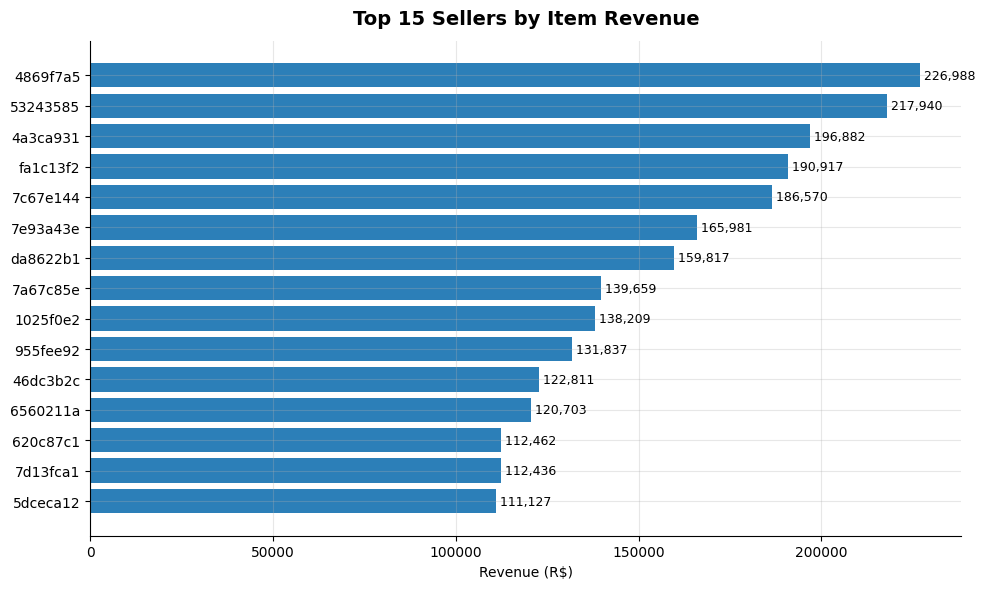

In [45]:
fig, ax = bar(sellers, "seller_short", "revenue",
              "Top 15 Sellers by Item Revenue", "Revenue (R$)")
save_fig(fig, "seller_revenue")
plt.show()

### Insight
- The top seller earns **R$ ___**; the top 15 together account for [roughly how much].
- [Is revenue concentrated? Do top sellers also have strong reviews / on-time %?]

### Recommendation
- [Action — e.g. protect top sellers, or coach high-revenue but low-rated ones]

## Q4 — Cohort Retention

**Question:** do customers acquired in different months return at different
rates?

**Context:** retention by acquisition cohort shows whether the business is
structurally repeat-driven or one-time-driven — which determines the entire
growth strategy.

In [46]:
cohorts = run_sql("cohort_retention.sql")
cohorts

,cohort_month,cohort_size,returned,retention_pct
0,2016-09,4,0,0.00
1,2016-10,321,12,3.74
2,2016-12,1,1,100.00
3,2017-01,764,58,7.59
4,2017-02,1752,73,4.17
5,2017-03,2636,130,4.93
6,2017-04,2352,108,4.59
7,2017-05,3596,198,5.51
8,2017-06,3139,173,5.51
9,2017-07,3894,186,4.78


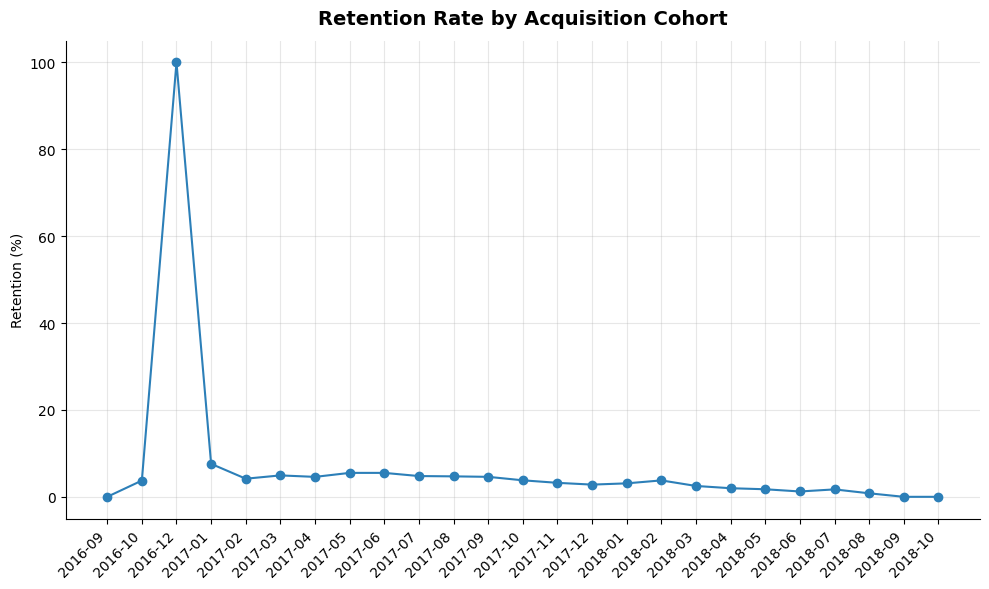

In [47]:
# Note: very early/late cohorts can be tiny — check cohort_size before
# over-reading their retention %.
fig, ax = line(cohorts, "cohort_month", "retention_pct",
               "Retention Rate by Acquisition Cohort", "Retention (%)")
save_fig(fig, "cohort_retention")
plt.show()

### Insight
- Retention sits around **___%** across cohorts.
- [Is it flat and low? What does that confirm about the marketplace?]

### Recommendation
- [Action that follows — likely about acquisition, not loyalty, if retention is low]

## Q5 — Logistics Bottlenecks

**Question:** which regions experience the slowest deliveries?

**Context:** Brazil's geography makes delivery uneven. Pinpointing the
slowest states shows where logistics investment would move the satisfaction
numbers most.

In [49]:
states = run_sql("pipeline_stages.sql").head(15)  # 15 slowest states
states

,customer_state,orders,avg_delivery_days
0,RR,41,29.4
1,AP,67,27.2
2,AM,145,26.4
3,AL,397,24.5
4,PA,946,23.8
5,MA,717,21.6
6,SE,335,21.5
7,CE,1279,21.3
8,AC,80,21.0
9,PB,517,20.4


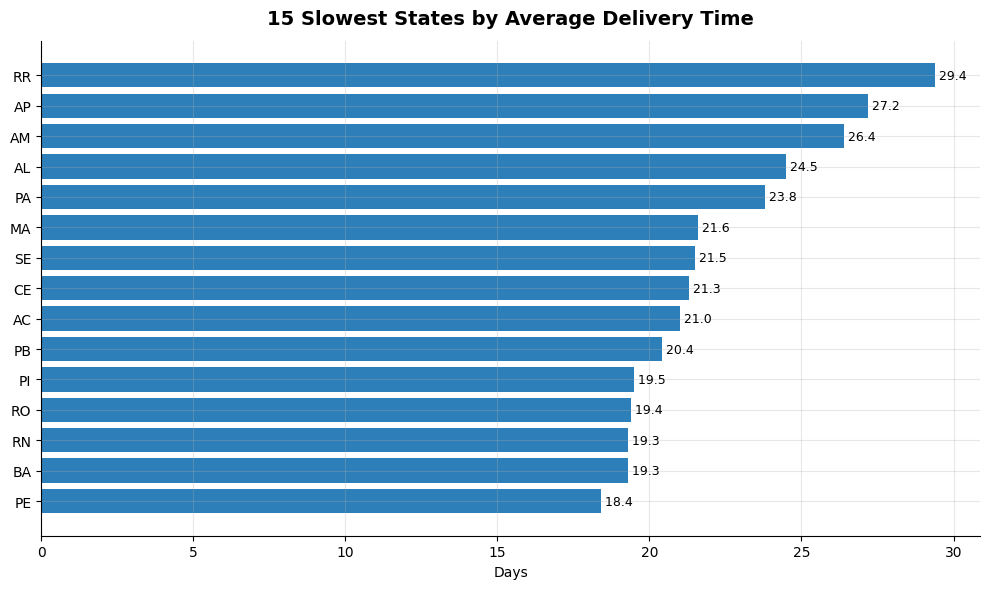

In [50]:
fig, ax = bar(states, "customer_state", "avg_delivery_days",
              "15 Slowest States by Average Delivery Time", "Days", fmt=".1f")
save_fig(fig, "slowest_states")
plt.show()

### Insight
- The slowest state is **___** at **___** days, vs the national average of
  **___** days (from the KPI snapshot).
- [Which region? How wide is the gap?]

### Recommendation
- [Action — e.g. carrier partnerships or warehousing in the slowest regions]

## Executive Summary

### Key Findings
1. [Retention — the one-time-purchase reality]
2. [Delivery's measured effect on reviews]
3. [Revenue concentration among sellers]
4. [Cohort consistency]
5. [Regional logistics gaps]

### Recommendations
1.
2.
3.

*Every number above is drawn from this notebook's own output.*